> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# **IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing**

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Business Context: Hotel Bookings

### Dataset Description:

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## **Task 1. Setup and Data Loading**

Instructions:

🔧 1.1. Import `pandas`, `seaborn`, and `matplotlib.pyplot`.

🔧 1.2. Load the dataset from this URL:
  https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/hotels.csv

🔧 1.3. Display some sample rows to confirm it loaded correctly.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/hotels.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## **Task 2. Stakeholder and Business Context**

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### 🔧 Please answer the following:

2.1. Who are the key stakeholders for this dataset?\
2.2. What goals might each stakeholder have?\
2.3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
2.1. Hotel managers, owners, and marketing teams.

2.2. The goals might include to increase bookings, reduce cancellations, and improve revenue.

2.3. What variables affect hotel booking cancellations and how can hotels reduce them?




## **Task 3. Explore Data Structure and Quality**

### Business framing:

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.



### 🔧 3.1 - 3.3. Use at least 3 techniques to examine structure and quality:
  - Summary info, summary statistics
  - Data Types
  - Missing value checks
  - Duplicate row checks
  - Detect Outliers



In [4]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

np.int64(31994)

### 🔧 Please answer the following:

3.4. What structural issues (e.g., missing values, incorrectly inferred data types, duplicates, outliers, or formatting problems) did you find?

3.5. What actions would you recommend to fix this structural issue?



### ✍️ Your Response: 🔧
3.4. There are missing values and 31,994 duplicate rows.

3.5. Remove duplicate rows and remove (or fill) missing values.

## **Task 4. Univariate Analysis**

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### 🔧 4.1 - 4.3 Select at least 3 individual variables to explore
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)
- Use plots and summaries to describe the distribution





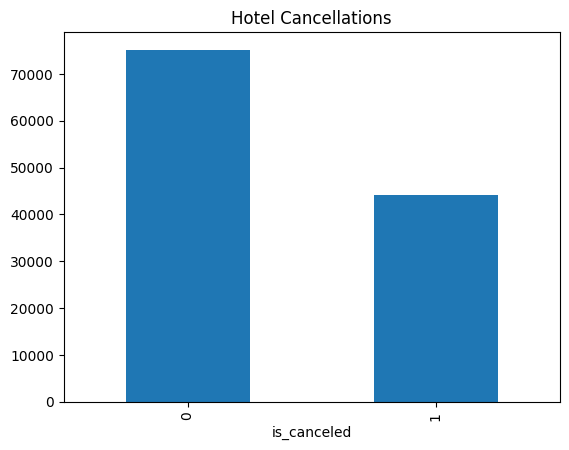

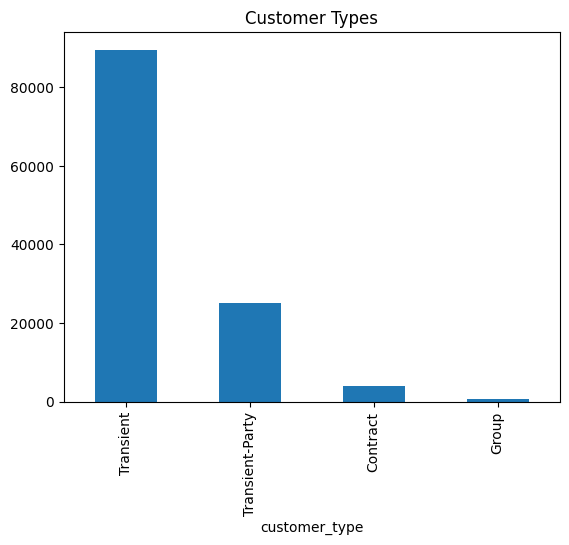

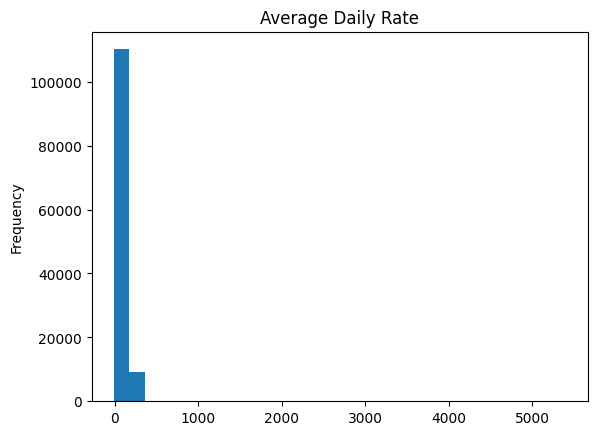

In [5]:
# 🔧 4.1. Your code for univariate analysis (e.g., plots, value counts) for variable 1
df['is_canceled'].value_counts().plot(kind='bar')
plt.title('Hotel Cancellations')
plt.show()

# 🔧 4.2. Your code for univariate analysis (e.g., plots, value counts) for variable 2
df['customer_type'].value_counts().plot(kind='bar')
plt.title('Customer Types')
plt.show()

# 🔧 4.3. Your code for univariate analysis (e.g., plots, value counts) for variable 3
df['adr'].plot(kind='hist', bins=30)
plt.title('Average Daily Rate')
plt.show()

### 🔧 Please answer the following:

4.4. Variable 1 - What did you explore and what did you find?

4.5. Variable 2 - What did you explore and what did you find?

4.6. Variable 3 - What did you explore and what did you find?

### ✍️ Your Response: 🔧

4.4. Variable 1 summary and insights: I explored hotel cancellations and found that most bookings were not canceled.

4.5. Variable 2 summary and insights: I explored customer types and found that most customers were Transient.

4.6. Variable 3 summary and insights: I explored average daily rates and saw that most rates were lower with a few very high outliers.

## **Task 5. Bivariate Analysis**

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

###  🔧 5.1 - 5.2 Choose 2 relevant variable pairs to examine
- such as (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships. If the relationship or trend is not cleanly visible, then change the type of chart.
- Interpret what these relationships could mean for the hotel business





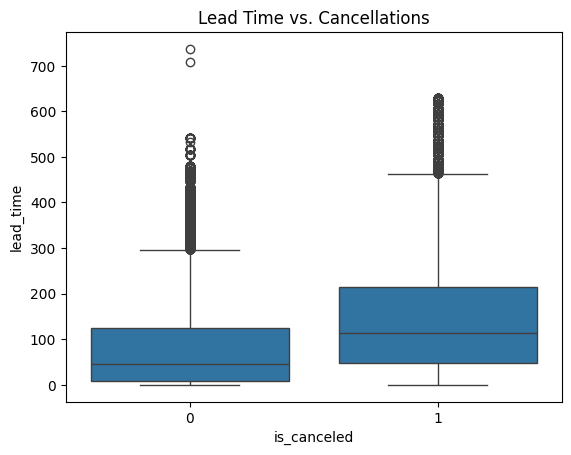

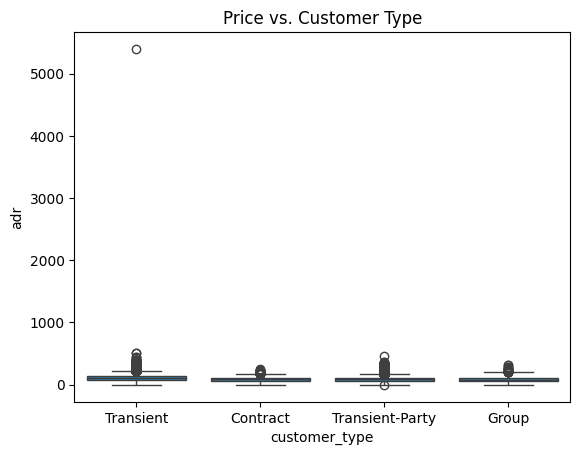

In [6]:
# 🔧 5.1 Your code to analyze variable relationships (e.g., scatterplots, grouped bars)
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time vs. Cancellations')
plt.show()


# 🔧 5.2 Your code to analyze variable relationships (e.g., scatterplots, grouped bars)
sns.boxplot(x='customer_type', y='adr', data=df)
plt.title('Price vs. Customer Type')
plt.show()

### 🔧 Please answer the following:

5.3. Relationship 1 - What did you analyze and what insights did you find?

5.4. Relationship 2 - What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧

5.3. Relationship 1: I analyzed lead time and cancellations. Canceled bookings had longer lead times.

5.4. Relationship 2: I analyzed price and customer type. Prices were similar across customer types there were only some outliers.


## **Task 6. Problem Complexity and Analytics Framing**

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

Choose one insight from your earlier analysis. Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)




### 🔧 Please answer the following:

6.1. What was your selected insight?

6.2. What kind of complexity does it involve?

6.3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧

6.1. Canceled bookings have longer lead times.

6.2. The complexity it involves is variability, because lead times vary between bookings.

6.3. I think predictive analytics, because it could help predict which bookings may be canceled.

## **Task 7. Reflections, Final Takeaways and Recommendations**

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### 🔧 Please answer the following:

7.1. What patterns or trends stood out?

7.2. How do they connect to stakeholder goals?

7.3. What recommendation would you make based on this analysis?

7.4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

7.1. Canceled bookings usually had longer lead times.

7.2. It connects by helping hotels reduce cancellations and improve revenue.

7.3. My recommendation would be that hotels should monitor bookings made far in advance for possible cancellations.

7.4. This helped towards my learning outcome which was how to use data analysis to make business decisions.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown/comment questions are answered thoughtfully in your own words
- Save the file with your last name and first name as shown below (see detailed instructions in Lab 1 on how to do this).
- Submit the assignment as an **HTML file** on Canvas

In [7]:
!jupyter nbconvert --to html "assignment_05_MaaloufNoelle.ipynb"

[NbConvertApp] Converting notebook assignment_05_MaaloufNoelle.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 436391 bytes to assignment_05_MaaloufNoelle.html
